In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Linear Regression Model

In [ ]:
grad3 = pd.read_csv('grad3.csv')

In [ ]:
grad3.head()

,Salary,GPA,Height,IQ,Busi,Faculty
0,21845,3.128418,168,111,0,1
1,22850,3.068629,168,107,0,1
2,25030,3.676808,170,128,0,1
3,21703,2.282585,170,104,0,1
4,23976,3.295502,170,127,0,1


In [ ]:
grad3.corr()        #corr matrix when one variable increases, will y also increase, it is show if two variables move the in the same direction, but it cant tell the effect

,Salary,GPA,Height,IQ,Busi,Faculty
Salary,1.000000,0.708521,0.059893,0.468733,0.126388,0.126388
GPA,0.708521,1.000000,0.018500,0.225183,0.146099,0.146099
Height,0.059893,0.018500,1.000000,0.075352,-0.064823,-0.064823
IQ,0.468733,0.225183,0.075352,1.000000,0.036572,0.036572
Busi,0.126388,0.146099,-0.064823,0.036572,1.000000,1.000000
Faculty,0.126388,0.146099,-0.064823,0.036572,1.000000,1.000000


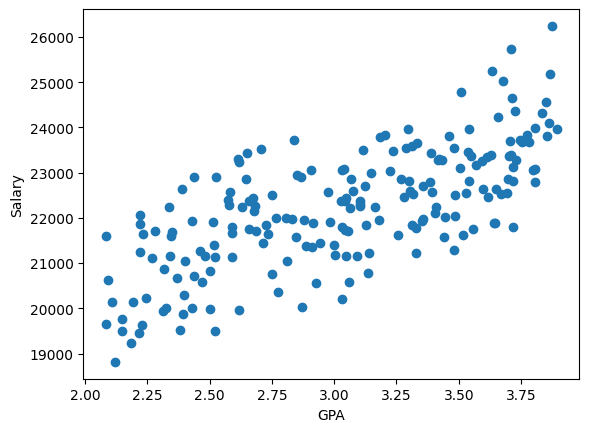

In [ ]:
plt.scatter(grad3['GPA'],grad3['Salary'])
plt.xlabel('GPA')
plt.ylabel('Salary')
plt.show()

In [ ]:
B1, B0 = np.polyfit(grad3['GPA'], grad3['Salary'], 1)
print(f"β₀ (intercept): {B0:.4f}")
print(f"β₁ (slope): {B1:.4f}")

β₀ (intercept): 16675.3098
β₁ (slope): 1825.8650


NameError: name 'a' is not defined

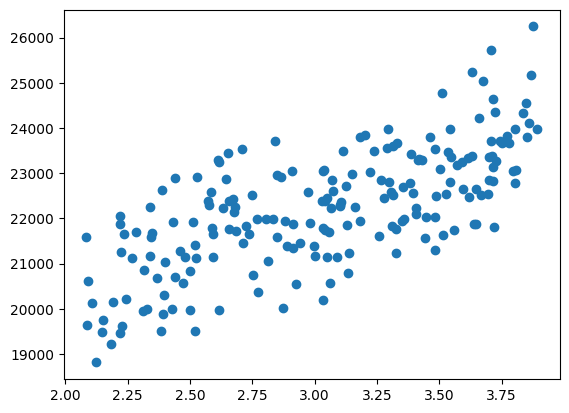

In [ ]:
plt.scatter(grad3['GPA'],grad3['Salary'])
plt.plot(grad3['GPA'], a*grad3['GPA'] + b, color='red')
plt.xlabel('GPA')
plt.ylabel('Salary')
plt.show()

## Single Independent Variable

In [ ]:
import statsmodels.api as sm

In [ ]:
#define x and y
x = grad3['GPA']
x = sm.add_constant(x)
x

,const,GPA
0,1.0,3.128418
1,1.0,3.068629
2,1.0,3.676808
3,1.0,2.282585
4,1.0,3.295502
...,...,...
195,1.0,2.767004
196,1.0,2.839816
197,1.0,2.880568
198,1.0,3.715845


In [ ]:
y = grad3['Salary']

In [ ]:
model = sm.OLS(y, x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.502
Model:                            OLS   Adj. R-squared:                  0.499
Method:                 Least Squares   F-statistic:                     199.6
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           8.43e-32
Time:                        03:22:43   Log-Likelihood:                -1652.2
No. Observations:                 200   AIC:                             3308.
Df Residuals:                     198   BIC:                             3315.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.668e+04    398.095     41.888      0.0

## Multiple Indepedent Variables

In [ ]:
X = grad3[['GPA', 'Height', 'IQ']]
X = sm.add_constant(x)
X

,const,GPA
0,1.0,3.128418
1,1.0,3.068629
2,1.0,3.676808
3,1.0,2.282585
4,1.0,3.295502
...,...,...
195,1.0,2.767004
196,1.0,2.839816
197,1.0,2.880568
198,1.0,3.715845


In [ ]:
model2 = sm.OLS(y, X).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.502
Model:                            OLS   Adj. R-squared:                  0.499
Method:                 Least Squares   F-statistic:                     199.6
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           8.43e-32
Time:                        03:22:55   Log-Likelihood:                -1652.2
No. Observations:                 200   AIC:                             3308.
Df Residuals:                     198   BIC:                             3315.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.668e+04    398.095     41.888      0.0

In [ ]:
x1 = grad3[['GPA', 'Height', 'IQ', 'Busi']]
x1 = sm.add_constant(x1)
x1

,const,GPA,Height,IQ,Busi
0,1.0,3.128418,168,111,0
1,1.0,3.068629,168,107,0
2,1.0,3.676808,170,128,0
3,1.0,2.282585,170,104,0
4,1.0,3.295502,170,127,0
...,...,...,...,...,...
195,1.0,2.767004,171,114,0
196,1.0,2.839816,171,126,0
197,1.0,2.880568,174,129,1
198,1.0,3.715845,168,124,1


In [ ]:
model3 = sm.OLS(y, x1).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.604
Model:                            OLS   Adj. R-squared:                  0.596
Method:                 Least Squares   F-statistic:                     74.30
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           3.73e-38
Time:                        03:23:02   Log-Likelihood:                -1629.3
No. Observations:                 200   AIC:                             3269.
Df Residuals:                     195   BIC:                             3285.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.007e+04   3018.826      3.335      0.0

In [ ]:
from statsmodels.stats.anova import anova_lm
anovaResults = anova_lm(model,model3)
print(anovaResults)

#p-value<5%, model3 is significantly better than model 1

   df_resid           ssr  df_diff       ss_diff          F        Pr(>F)
0     198.0  1.752916e+08      0.0           NaN        NaN           NaN
1     195.0  1.394521e+08      3.0  3.583957e+07  16.705182  1.064088e-09


In [ ]:
x6 = grad3[['GPA', 'Height', 'IQ', 'Busi', 'Faculty']]
x6 = sm.add_constant(x6)
x6

,const,GPA,Height,IQ,Busi,Faculty
0,1.0,3.128418,168,111,0,1
1,1.0,3.068629,168,107,0,1
2,1.0,3.676808,170,128,0,1
3,1.0,2.282585,170,104,0,1
4,1.0,3.295502,170,127,0,1
...,...,...,...,...,...,...
195,1.0,2.767004,171,114,0,1
196,1.0,2.839816,171,126,0,1
197,1.0,2.880568,174,129,1,2
198,1.0,3.715845,168,124,1,2


In [ ]:
model6= sm.OLS(y, x6).fit()
print(model6.summary())

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.604
Model:                            OLS   Adj. R-squared:                  0.596
Method:                 Least Squares   F-statistic:                     74.30
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           3.73e-38
Time:                        03:23:33   Log-Likelihood:                -1629.3
No. Observations:                 200   AIC:                             3269.
Df Residuals:                     195   BIC:                             3285.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6689.3241   2015.687      3.319      0.0

## Making Predictions

In [ ]:
#x variables
new_grad = pd.DataFrame({
    'constant':[1],
    'GPA': [3.6],
    'Height': [176],
    'IQ': [118],
    'Busi':[1]
})
new_grad

,constant,GPA,Height,IQ,Busi
0,1,3.6,176,118,1


In [ ]:
model3.predict(new_grad)

,0
0,23400.096723


## Interaction Terms

In [ ]:
import statsmodels.formula.api as smf

In [ ]:
formula = 'Salary ~ GPA * Busi'

In [ ]:
model7 = smf.ols(formula, grad3).fit()
print(model7.summary())

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.504
Model:                            OLS   Adj. R-squared:                  0.496
Method:                 Least Squares   F-statistic:                     66.39
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           1.14e-29
Time:                        03:35:58   Log-Likelihood:                -1651.7
No. Observations:                 200   AIC:                             3311.
Df Residuals:                     196   BIC:                             3325.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    1.69e+04    488.309     34.600      0.0

In [ ]:
# GPA: Busi == extra effect of gpa of busi students in salary amount

###GPA predicts salary equally well for ALL majors. There is NO evidence that business majors get a different GPA 'return' on their salary.


## Standardizing Variables

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
grad_std = pd.DataFrame(scaler.fit_transform(grad3), columns = grad3.columns)


In [ ]:
grad_std.describe()

,Salary,GPA,Height,IQ,Busi,Faculty
count,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02
mean,-4.440892e-18,-5.773160e-16,-1.776357e-17,-8.881784e-18,2.664535e-17,1.421085e-16
std,1.002509e+00,1.002509e+00,1.002509e+00,1.002509e+00,1.002509e+00,1.002509e+00
min,-2.567677e+00,-1.851188e+00,-1.734945e+00,-1.628700e+00,-6.938887e-01,-6.938887e-01
25%,-6.181987e-01,-8.667259e-01,-8.674724e-01,-8.424308e-01,-6.938887e-01,-6.938887e-01
50%,2.270780e-02,4.246777e-02,0.000000e+00,-5.616205e-02,-6.938887e-01,-6.938887e-01
75%,6.673832e-01,8.700373e-01,8.674724e-01,8.705118e-01,1.441153e+00,1.441153e+00
max,3.034459e+00,1.662992e+00,1.734945e+00,1.741024e+00,1.441153e+00,1.441153e+00


In [ ]:
# Standardize all numeric columns
standardized_data = (grad3 - grad3.mean()) / grad3.std()
standardized_data

,Salary,GPA,Height,IQ,Busi,Faculty
0,-0.282244,0.177229,-0.865301,-0.392150,-0.692152,-0.692152
1,0.473414,0.061378,-0.865301,-0.840322,-0.692152,-0.692152
2,2.112554,1.239815,-0.288434,1.512580,-0.692152,-0.692152
3,-0.389014,-1.461701,-0.288434,-1.176451,-0.692152,-0.692152
4,1.320053,0.500979,-0.288434,1.400537,-0.692152,-0.692152
...,...,...,...,...,...,...
195,-0.173971,-0.523066,0.000000,-0.056021,-0.692152,-0.692152
196,1.126063,-0.381981,0.000000,1.288494,-0.692152,-0.692152
197,-0.208558,-0.303017,0.865301,1.624623,1.437546,1.437546
198,0.449354,1.315457,-0.865301,1.064408,1.437546,1.437546


In [ ]:
grad_std.head()     #-0.28295 means the salary of the graduate is 0.2829 SD lower than the average salary

,Salary,GPA,Height,IQ,Busi,Faculty
0,-0.282952,0.177674,-0.867472,-0.393134,-0.693889,-0.693889
1,0.474602,0.061532,-0.867472,-0.842431,-0.693889,-0.693889
2,2.117856,1.242927,-0.289157,1.516375,-0.693889,-0.693889
3,-0.389990,-1.465369,-0.289157,-1.179403,-0.693889,-0.693889
4,1.323365,0.502236,-0.289157,1.404051,-0.693889,-0.693889


In [ ]:
x8 = grad_std[['GPA', 'Height', 'IQ']]
x8 = sm.add_constant(x8)
y = grad_std['Salary']

In [ ]:
model8 = sm.OLS(y, x8).fit()
print(model8.summary())

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.603
Model:                            OLS   Adj. R-squared:                  0.597
Method:                 Least Squares   F-statistic:                     99.34
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           3.93e-39
Time:                        03:56:35   Log-Likelihood:                -191.34
No. Observations:                 200   AIC:                             390.7
Df Residuals:                     196   BIC:                             403.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const               0      0.045          0      1.0

## Coefficient Plots

In [ ]:
coef_sum = model8.summary2().tables[1][1:4]
coef_sum = coef_sum.reset_index()

In [ ]:
coef_sum

,index,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
0,GPA,0.635141,0.046177,13.754573,1.420815e-30,0.544074,0.726208
1,Height,0.023735,0.045119,0.526047,5.994506e-01,-0.065246,0.112716
2,IQ,0.323921,0.046300,6.996075,4.063661e-11,0.232610,0.415232


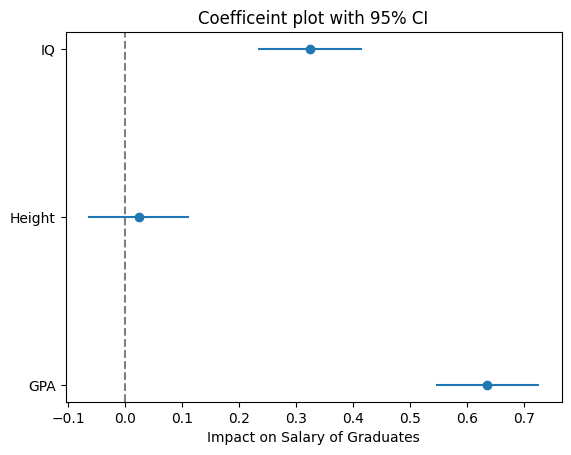

In [ ]:
plt.errorbar(coef_sum['Coef.'], coef_sum['index'], xerr = coef_sum['Std.Err.']*1.96,fmt='o')
plt.axvline(x=0, color ='grey', linestyle ='--')
plt.title('Coefficeint plot with 95% CI')
plt.xlabel('Impact on Salary of Graduates')
plt.show()
# GPA and IQ are significant indicators of Graduate Salary

# Exercise

In [ ]:
hotel = pd.read_csv('hotelsat-data.csv')

hotel

## 1)
What are the patterns of
correlations in the data?

In [ ]:
hotel.columns

Index(['satCleanRoom', 'satCleanBath', 'satCleanCommon', 'satFrontStaff',
       'satDiningStaff', 'satHouseStaff', 'satValetStaff', 'satPerks',
       'satRoomPrice', 'satDiningPrice', 'satWifiPrice', 'satParkingPrice',
       'satCity', 'satCloseTransp', 'satCloseEvents', 'satPoints',
       'satRecognition', 'satOverall', 'distanceTraveled', 'nightsStayed',
       'visitPurpose', 'avgRoomSpendPerNight', 'avgFoodSpendPerNight',
       'avgWifiSpendPerNight', 'eliteStatus'],
      dtype='object')

In [ ]:
hotel.corr(numeric_only=True)

## 2a
Management wants to know whether satisfaction with elite
membership perks (satPerks) predicts overall satisfaction
(satOverall). How do you model and interpret the
relationship?

In [ ]:
x = hotel['satPerks']
x = sm.add_constant(x)
x

In [ ]:
y = hotel['satOverall']

In [ ]:
model4 = sm.OLS(y, x).fit()
print(model4.summary())

## 2b)
Control the Perks model for other influences: satisfaction
with the Front Staff (satFrontStaff) and with the hotel city
(satCity). How would you change the previous model?

In [ ]:
x2 = hotel[['satPerks','satFrontStaff', 'satCity']]
x2 = sm.add_constant(x2)
x2

In [ ]:
model5 = sm.OLS(y, x2).fit()
print(model5.summary())

In [ ]:
anovaResults = anova_lm(model4,model5)
print(anovaResults)
# model 2 is significantly better than model 1

### 3a)
Explore the influence of satisfaction with front staff (satFrontStaff),
room cleanliness (satCleanRoom), points given (satPoints), and
membership perks(satPerks). Would you recommend to invest more
in cleanliness?


In [ ]:
x3a = hotel[['satPerks','satFrontStaff', 'satCleanRoom', 'satPoints']]
x3a = sm.add_constant(x3a)
x3a

,const,satPerks,satFrontStaff,satCleanRoom,satPoints
0,1.0,3,2,6,4
1,1.0,6,5,4,4
2,1.0,4,5,5,4
3,1.0,3,3,4,2
4,1.0,4,4,2,3
...,...,...,...,...,...
1495,1.0,4,4,3,3
1496,1.0,3,3,4,2
1497,1.0,3,4,4,4
1498,1.0,6,5,4,6


In [ ]:
model9 = sm.OLS(y, x3a).fit()
print(model9.summary())

                            OLS Regression Results                            
Dep. Variable:             satOverall   R-squared:                       0.299
Model:                            OLS   Adj. R-squared:                  0.297
Method:                 Least Squares   F-statistic:                     159.3
Date:                Thu, 26 Mar 2026   Prob (F-statistic):          1.17e-113
Time:                        04:13:11   Log-Likelihood:                -2069.0
No. Observations:                1500   AIC:                             4148.
Df Residuals:                    1495   BIC:                             4174.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             1.0937      0.129      8.510

## 3b)
Based on this model, for a customer with satCleanRoom at 5,
satFrontStaff at 2, satPoints at 3, and satPerks at 5, what is the
predicted satisfaction with elite recognition?

In [ ]:
#x variables
hotel_sat = pd.DataFrame({
    'constant':[1],
    'satCleanRoom': [5],
    'satFrontStaff': [2],
    'satPoints': [3],
    'satPerks':[5]
})
hotel_sat

,constant,satCleanRoom,satFrontStaff,satPoints,satPerks
0,1,5,2,3,5


In [ ]:
model9.predict(hotel_sat)

,0
0,3.31567
